In [2]:
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


In [3]:
import os

data_dir = "/drive/MyDrive/nasa_log_predict_proj/data"

print("데이터 저장 경로:", data_dir)
print("현재 data 폴더 안 파일들:", os.listdir(data_dir))

데이터 저장 경로: /drive/MyDrive/nasa_log_predict_proj/data
현재 data 폴더 안 파일들: ['NASA_access_log_Jul95.gz', 'NASA_access_log_Jul95']


In [4]:
import urllib.request

url = "https://ita.ee.lbl.gov/traces/NASA_access_log_Jul95.gz"
gz_path = os.path.join(data_dir, "NASA_access_log_Jul95.gz")

if not os.path.exists(gz_path):
    urllib.request.urlretrieve(url, gz_path)
    print("다운로드 완료:", gz_path)
else:
    print("이미 존재함:", gz_path)

이미 존재함: /drive/MyDrive/nasa_log_predict_proj/data/NASA_access_log_Jul95.gz


In [5]:
import gzip
import shutil

log_path = os.path.join(data_dir, "NASA_access_log_Jul95")

if not os.path.exists(log_path):
    with gzip.open(gz_path, 'rb') as f_in:
        with open(log_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("압축 해제 완료:", log_path)
else:
    print("이미 압축 해제된 파일 존재:", log_path)

이미 압축 해제된 파일 존재: /drive/MyDrive/nasa_log_predict_proj/data/NASA_access_log_Jul95


In [6]:
print("data 폴더 파일 목록:")
for f in os.listdir(data_dir):
    print("-", f)

data 폴더 파일 목록:
- NASA_access_log_Jul95.gz
- NASA_access_log_Jul95


In [7]:
with open(log_path, "r", encoding="latin-1") as f:
    lines = f.readlines()

print("총 로그 줄 수:", len(lines))
print("\n샘플 5줄:")
for line in lines[:5]:
    print(line.strip())

총 로그 줄 수: 1891715

샘플 5줄:
199.72.81.55 - - [01/Jul/1995:00:00:01 -0400] "GET /history/apollo/ HTTP/1.0" 200 6245
unicomp6.unicomp.net - - [01/Jul/1995:00:00:06 -0400] "GET /shuttle/countdown/ HTTP/1.0" 200 3985
199.120.110.21 - - [01/Jul/1995:00:00:09 -0400] "GET /shuttle/missions/sts-73/mission-sts-73.html HTTP/1.0" 200 4085
burger.letters.com - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/countdown/liftoff.html HTTP/1.0" 304 0
199.120.110.21 - - [01/Jul/1995:00:00:11 -0400] "GET /shuttle/missions/sts-73/sts-73-patch-small.gif HTTP/1.0" 200 4179


In [8]:
import re
import pandas as pd

pattern = re.compile(
    r'(\S+) (\S+) (\S+) \[(.*?)\] "(.*?)" (\S+) (\S+)'
)

parsed_data = []

for line in lines:
    match = pattern.match(line)
    if match:
        host, ident, authuser, date, request, status, bytes_ = match.groups()
        parsed_data.append([host, ident, authuser, date, request, status, bytes_])

df = pd.DataFrame(
    parsed_data,
    columns=["host", "ident", "authuser", "date", "request", "status", "bytes"]
)

print("파싱된 행 수:", len(df))
df.head()

파싱된 행 수: 1891714


,host,ident,authuser,date,request,status,bytes
0,199.72.81.55,-,-,01/Jul/1995:00:00:01 -0400,GET /history/apollo/ HTTP/1.0,200,6245
1,unicomp6.unicomp.net,-,-,01/Jul/1995:00:00:06 -0400,GET /shuttle/countdown/ HTTP/1.0,200,3985
2,199.120.110.21,-,-,01/Jul/1995:00:00:09 -0400,GET /shuttle/missions/sts-73/mission-sts-73.ht...,200,4085
3,burger.letters.com,-,-,01/Jul/1995:00:00:11 -0400,GET /shuttle/countdown/liftoff.html HTTP/1.0,304,0
4,199.120.110.21,-,-,01/Jul/1995:00:00:11 -0400,GET /shuttle/missions/sts-73/sts-73-patch-smal...,200,4179


In [9]:
df["datetime"] = pd.to_datetime(
    df["date"],
    format="%d/%b/%Y:%H:%M:%S %z",
    errors="coerce"
)

df = df.dropna(subset=["datetime"]).copy()

print("datetime 변환 후 행 수:", len(df))
print(df[["date", "datetime"]].head())

datetime 변환 후 행 수: 1891714
                         date                  datetime
0  01/Jul/1995:00:00:01 -0400 1995-07-01 00:00:01-04:00
1  01/Jul/1995:00:00:06 -0400 1995-07-01 00:00:06-04:00
2  01/Jul/1995:00:00:09 -0400 1995-07-01 00:00:09-04:00
3  01/Jul/1995:00:00:11 -0400 1995-07-01 00:00:11-04:00
4  01/Jul/1995:00:00:11 -0400 1995-07-01 00:00:11-04:00


In [10]:
df["hour"] = df["datetime"].dt.floor("h")

hourly_requests = df.groupby("hour").size().reset_index(name="requests")
hourly_requests = hourly_requests.sort_values("hour").reset_index(drop=True)

print(hourly_requests.head())
print("총 시간 단위 데이터 개수:", len(hourly_requests))

                       hour  requests
0 1995-07-01 00:00:00-04:00      3565
1 1995-07-01 01:00:00-04:00      3004
2 1995-07-01 02:00:00-04:00      2268
3 1995-07-01 03:00:00-04:00      1734
4 1995-07-01 04:00:00-04:00      1482
총 시간 단위 데이터 개수: 662


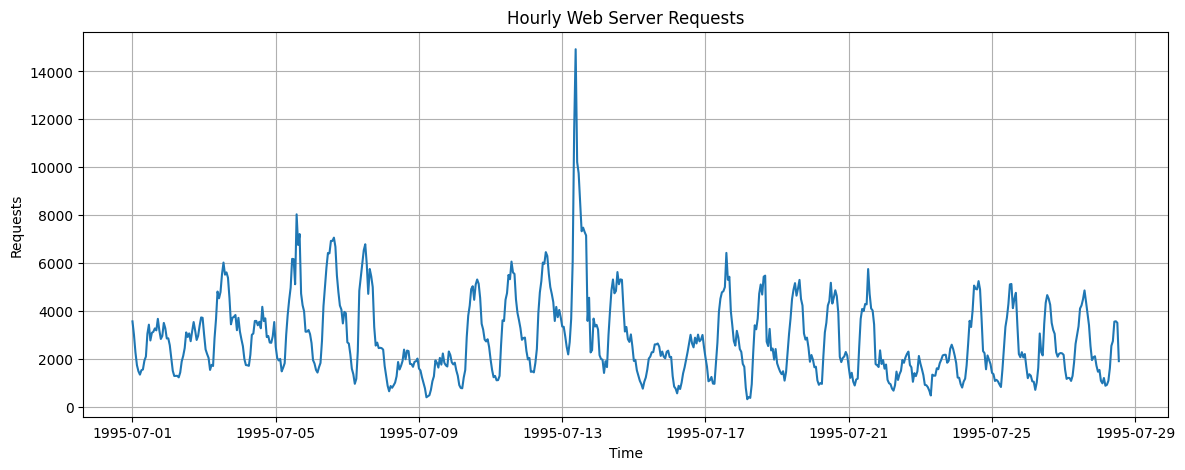

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(hourly_requests["hour"], hourly_requests["requests"])
plt.title("Hourly Web Server Requests")
plt.xlabel("Time")
plt.ylabel("Requests")
plt.grid(True)
plt.show()

In [12]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

values = hourly_requests["requests"].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

print("원본 shape:", values.shape)
print("정규화 shape:", scaled_values.shape)

원본 shape: (662, 1)
정규화 shape: (662, 1)


In [13]:
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24
X, y = create_sequences(scaled_values, seq_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (638, 24, 1)
y shape: (638, 1)


In [14]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (510, 24, 1)
X_test : (128, 24, 1)
y_train: (510, 1)
y_test : (128, 1)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 151ms/step - loss: 0.0225 - val_loss: 0.0081
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0149 - val_loss: 0.0085
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0129 - val_loss: 0.0073
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0122 - val_loss: 0.0072
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0113 - val_loss: 0.0062
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0104 - val_loss: 0.0053
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0089 - val_loss: 0.0046
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0074 - val_loss: 0.0032
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0062 - val_loss: 0.0025
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0058 - val_loss: 0.0025
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0060 - val_loss: 0.0025
Epoch 12/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.

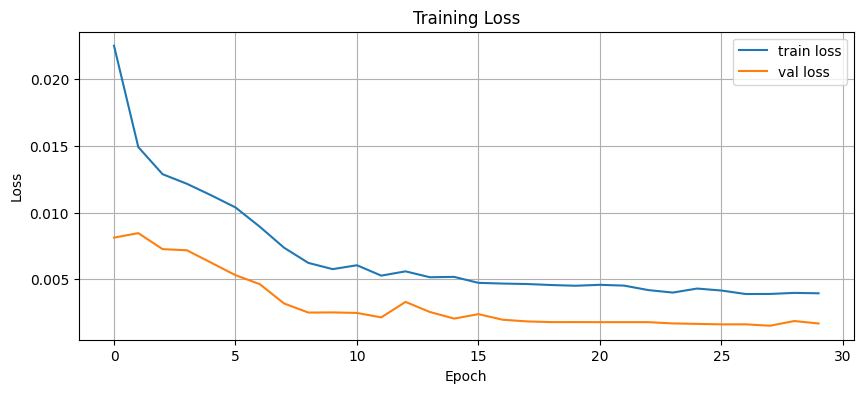

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

그래프가 '/drive/MyDrive/nasa_log_predict_proj/outputs/training_loss_plot.png' 경로에 저장되었습니다.


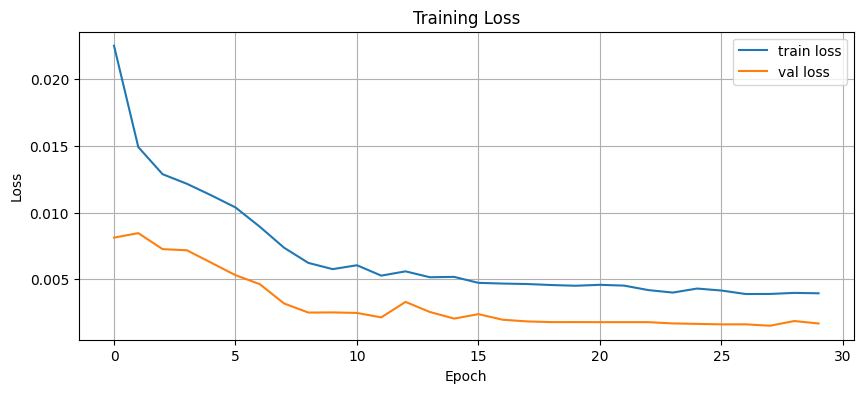

In [23]:
import matplotlib.pyplot as plt
import os

# 출력 폴더 정의
output_dir = os.path.join("/drive/MyDrive/nasa_log_predict_proj", "outputs")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 그래프 그리기 (기존 코드 재사용)
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# 그래프를 파일로 저장
output_filepath = os.path.join(output_dir, "training_loss_plot.png")
plt.savefig(output_filepath)
print(f"그래프가 '{output_filepath}' 경로에 저장되었습니다.")

# (선택 사항) 화면에도 표시하고 싶다면 아래 주석 해제
plt.show()

In [19]:
predictions = model.predict(X_test)

predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

print("예측 결과 shape:", predictions_inv.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
예측 결과 shape: (128, 1)


그래프가 '/drive/MyDrive/nasa_log_predict_proj/outputs/actual_vs_predicted_requests_plot.png' 경로에 저장되었습니다.


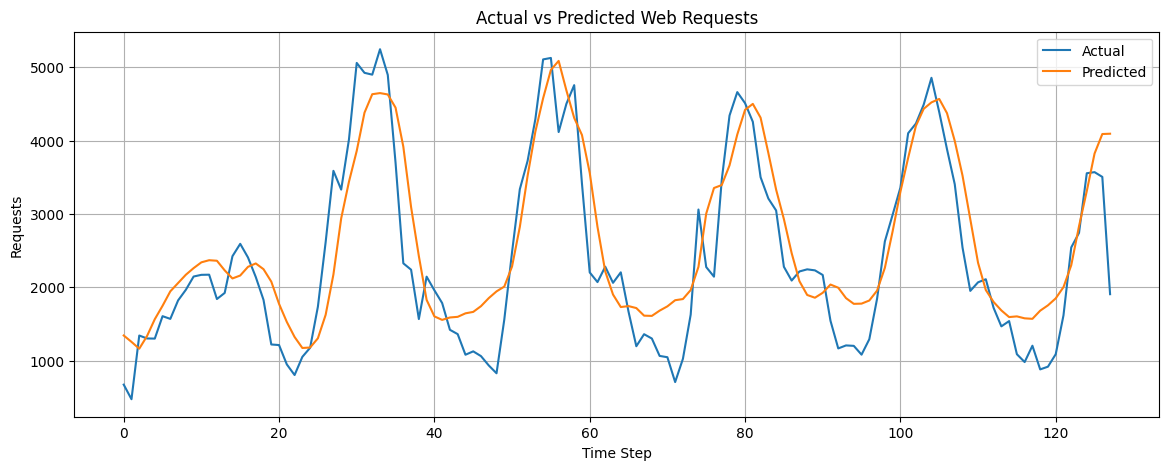

In [24]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(14, 5))
plt.plot(y_test_inv, label="Actual")
plt.plot(predictions_inv, label="Predicted")
plt.title("Actual vs Predicted Web Requests")
plt.xlabel("Time Step")
plt.ylabel("Requests")
plt.legend()
plt.grid(True)

# 출력 폴더 정의
output_dir = os.path.join("/drive/MyDrive/nasa_log_predict_proj", "outputs")
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 그래프를 파일로 저장
output_filepath = os.path.join(output_dir, "actual_vs_predicted_requests_plot.png")
plt.savefig(output_filepath)
print(f"그래프가 '{output_filepath}' 경로에 저장되었습니다.")

plt.show()

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test_inv, predictions_inv)
mae = mean_absolute_error(y_test_inv, predictions_inv)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 481.08420848846436
MSE : 357332.82902341767
RMSE: 597.7732254153055


In [22]:
last_sequence = scaled_values[-seq_length:]
last_sequence = last_sequence.reshape(1, seq_length, 1)

next_pred = model.predict(last_sequence)
next_pred_inv = scaler.inverse_transform(next_pred)

print("다음 1시간 예상 요청 수:", float(next_pred_inv[0][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
다음 1시간 예상 요청 수: 3471.22021484375
